<a href="https://colab.research.google.com/github/alt-gabby/qml-assignments/blob/main/5_Quantum_Boltzman_Machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Quantum Boltzmann Machine — Amin et al. (2018)
  N=4 qubits | M=4 modes | Γ=2.0 | η=0.05 | 200 iters

── Step 2: Generating Bernoulli mixture data ──
  Data distribution shape : (16,)
  Mode centres (spin configs):
  [[ 1  1  1  1]
 [ 1  1  1 -1]
 [-1 -1 -1  1]
 [ 1 -1 -1  1]]

  Shannon entropy of P_data : 2.2245 nats

── Step 4a: Training bQBM ──
  [bQBM] iter   50  KL = 0.10256
  [bQBM] iter  100  KL = 0.02996
  [bQBM] iter  150  KL = 0.01263
  [bQBM] iter  200  KL = 0.00709

── Step 4b: Training classical BM ──
  [BM]   iter   50  KL = 0.01571
  [BM]   iter  100  KL = 0.00553
  [BM]   iter  150  KL = 0.00410
  [BM]   iter  200  KL = 0.00374

  RESULTS SUMMARY
  bQBM  final KL : 0.007022
  BM    final KL : 0.003731
  ΔKL (BM - bQBM): -0.003290  (BM wins)

  Final learned parameters (bQBM):
    b = [ 1.1151 -0.0068  0.0053  1.114 ]
    w =
[[ 0.      0.7896  0.8124  0.1203]
 [ 0.      0.      2.029  -0.7834]
 [ 0.      0.      0.     -0.8164]
 [ 0.      0.      0.      0.    ]]

──

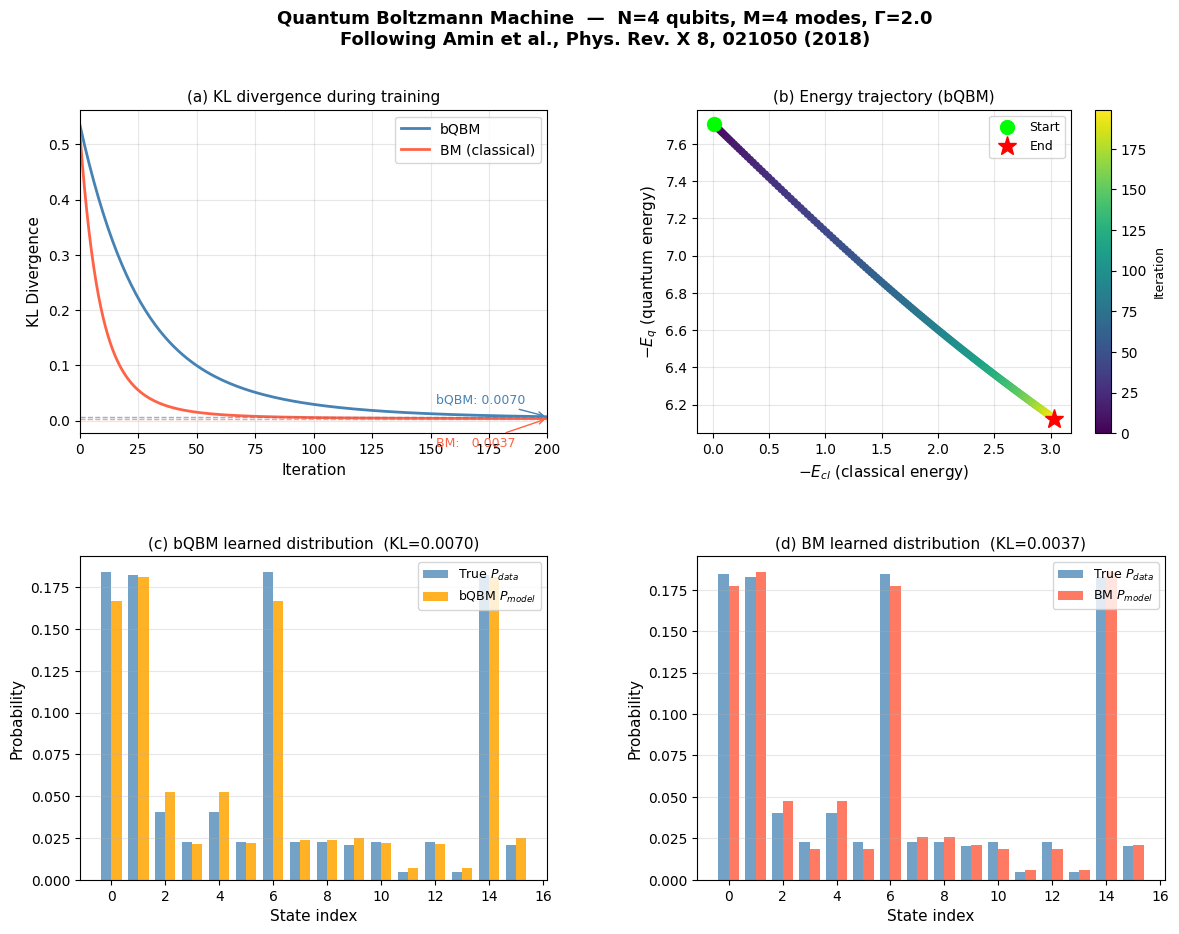

In [7]:
"""
Exercise 5: Quantum Boltzmann Machine (QBM)
Following Amin et al., Physical Review X 8, 021050 (2018)

Structure:
  Step 1 — Pauli operators and Hamiltonian construction
  Step 2 — Toy data: Bernoulli mixture model
  Step 3 — bQBM and classical BM gradient updates
  Step 4 — Training loop
  Step 5 — Plots: KL divergence, energy, learned vs true distribution
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product

np.random.seed(42)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Pauli operators, Hamiltonian, quantum Boltzmann distribution
# ══════════════════════════════════════════════════════════════════════════════

# ── 1.1  Single-qubit Pauli matrices ─────────────────────────────────────────
I2 = np.eye(2)
sx = np.array([[0., 1.], [1., 0.]])   # sigma_x
sz = np.array([[1., 0.], [0.,-1.]])   # sigma_z


def kron_op(op, a, N):
    """
    Embed single-qubit operator `op` on qubit a (0-indexed) into the full
    2^N x 2^N Hilbert space via tensor products (paper Eq. 10).

        sigma_a = I x ... x I x op x I x ... x I
                  |---- a-1 ----|       |-- N-a --|
    """
    mats = [I2] * N
    mats[a] = op
    result = mats[0]
    for m in mats[1:]:
        result = np.kron(result, m)
    return result


def build_hamiltonian(b, w, Gamma, N):
    """
    Transverse-field Ising Hamiltonian (paper Eq. 16):

        H = -Gamma * sum_a sx_a  -  sum_a b_a sz_a  -  sum_{a<b} w_ab sz_a sz_b

    Args:
        b     : (N,)   bias vector
        w     : (N, N) coupling matrix, upper triangle used
        Gamma : float  transverse field (same on every qubit)
        N     : int    number of qubits

    Returns:
        H : (2^N, 2^N) real symmetric matrix
    """
    dim = 2 ** N
    H = np.zeros((dim, dim))

    for a in range(N):
        H -= Gamma * kron_op(sx, a, N)          # transverse field
        H -= b[a]  * kron_op(sz, a, N)          # longitudinal bias

    for a in range(N):
        for c in range(a + 1, N):
            SzSz = kron_op(sz, a, N) @ kron_op(sz, c, N)
            H -= w[a, c] * SzSz                  # spin-spin coupling

    return H


def quantum_boltzmann(H):
    """
    Exact diagonalisation → quantum Boltzmann distribution.

    Computes:
        rho = Z^{-1} exp(-H)       (paper Eq. 12)
        P_v = <v| rho |v>          (paper Eq. 13, fully visible model)

    Returns:
        P   : (2^N,) probability vector
        rho : (2^N, 2^N) density matrix
    """
    eigvals, eigvecs = np.linalg.eigh(H)          # H symmetric → eigh
    exp_neg_H = eigvecs @ np.diag(np.exp(-eigvals)) @ eigvecs.T
    Z   = np.trace(exp_neg_H)
    rho = exp_neg_H / Z
    P   = np.real(np.diag(rho))                   # diagonal = measurement probs
    return P, rho


def state_to_spins(v, N):
    """
    Map state index v (0 … 2^N-1) to a spin configuration in {+1, -1}^N.
    Lexicographic convention: bit 0 (MSB) → qubit 0.
    E.g. N=2: 0→(+1,+1), 1→(+1,-1), 2→(-1,+1), 3→(-1,-1)
    """
    return np.array([1 - 2 * int(b) for b in format(v, f'0{N}b')])


def all_spin_configs(N):
    """Return (2^N, N) array of all spin configurations."""
    return np.array([state_to_spins(v, N) for v in range(2 ** N)])


# ── 1.2  Classical energy (Gamma = 0 limit) ──────────────────────────────────
def classical_energy(spins, b, w):
    """
    E_z = -sum_a b_a z_a  -  sum_{a<b} w_ab z_a z_b   (paper Eq. 1)

    Args:
        spins : (N,) or (2^N, N) spin configurations
        b, w  : bias and coupling parameters
    """
    if spins.ndim == 1:
        return -b @ spins - sum(
            w[a, c] * spins[a] * spins[c]
            for a in range(len(b)) for c in range(a + 1, len(b))
        )
    # Vectorised over all states
    E = -spins @ b
    N = spins.shape[1]
    for a in range(N):
        for c in range(a + 1, N):
            E -= w[a, c] * spins[:, a] * spins[:, c]
    return E


def classical_boltzmann(b, w, N):
    """
    Classical Boltzmann distribution (Gamma = 0):
        P_v = Z^{-1} exp(-E_v)
    """
    S   = all_spin_configs(N)
    E   = classical_energy(S, b, w)
    P   = np.exp(-E)
    return P / P.sum()


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Toy data: Bernoulli mixture model  (paper Eq. 53)
# ══════════════════════════════════════════════════════════════════════════════

def bernoulli_mixture(N, M, p=0.9, n_samples=1000, rng=None):
    """
    Generate a data distribution from M factorised Bernoulli modes.

    Each mode k has a random centre s^k in {+1,-1}^N.
    The probability of state v under mode k is:

        p^{N - d(v, s^k)} * (1-p)^{d(v, s^k)}

    where d is the Hamming distance (paper Eq. 53).

    Returns:
        P_data : (2^N,) true distribution (averaged over modes)
        samples: (n_samples, N) spin samples drawn from P_data
        centers: (M, N) mode centres
    """
    if rng is None:
        rng = np.random.default_rng(42)

    dim    = 2 ** N
    S      = all_spin_configs(N)          # (2^N, N)

    # Random mode centres in {+1, -1}^N
    centers = rng.choice([-1, 1], size=(M, N))

    P_data = np.zeros(dim)
    for k in range(M):
        # Hamming distance: number of positions where v and s^k differ
        # In {+1,-1} convention: differ ↔ s^k_i * v_i = -1
        hamming = ((S * centers[k]) < 0).sum(axis=1)   # (2^N,)
        P_data += p ** (N - hamming) * (1 - p) ** hamming

    P_data /= P_data.sum()

    # Draw samples
    state_indices = rng.choice(dim, size=n_samples, p=P_data)
    samples = S[state_indices]

    return P_data, samples, centers


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Gradient updates for bQBM and classical BM
# ══════════════════════════════════════════════════════════════════════════════

def kl_divergence(P_data, P_model, eps=1e-12):
    """
    KL(P_data || P_model) = sum_v P_data_v log(P_data_v / P_model_v)
    (paper Eq. 54)
    """
    mask = P_data > eps
    return np.sum(P_data[mask] * np.log(P_data[mask] / np.maximum(P_model[mask], eps)))


# ── 3.1  bQBM gradient (paper Eqs. 28, 30, 31) ───────────────────────────────
#
# Upper-bound loss:
#   L̃ = -sum_v P_data_v  log[ Tr(e^{-H_v}) / Tr(e^{-H}) ]
#
# Gradient steps:
#   δb_a   = η ( <sz_a>_v  - <sz_a> )
#   δw_ab  = η ( <sz_a sz_b>_v - <sz_a sz_b> )
#
# Fully visible model:
#   Positive phase (clamped): <sz_a>_v = v_a  (spin value of qubit a in state v)
#   Negative phase (free):    <sz_a>   = sum_v P_v * v_a   (from quantum dist.)

def bqbm_gradients(b, w, Gamma, N, P_data):
    """
    Compute bQBM gradient updates for b and w.

    Positive phase: expectation values under the clamped (data) distribution.
    Negative phase: expectation values under the free quantum distribution.

    Returns:
        grad_b : (N,)   gradient of L̃ w.r.t. b
        grad_w : (N, N) gradient of L̃ w.r.t. w  (upper triangle)
        P_model: (2^N,) current model distribution
        KL     : float  current KL divergence
    """
    S = all_spin_configs(N)   # (2^N, N)  each row is a spin config

    # ── Negative phase: free quantum Boltzmann distribution ──────────────────
    H       = build_hamiltonian(b, w, Gamma, N)
    P_model, _ = quantum_boltzmann(H)

    # <sz_a>   = sum_v P_v * s_a(v)
    neg_sz  = P_model @ S                         # (N,)

    # <sz_a sz_b> = sum_v P_v * s_a(v) * s_b(v)
    neg_szsz = (P_model[:, None] * S).T @ S       # (N, N)

    # ── Positive phase: clamped (data) averages ───────────────────────────────
    # For fully visible model: <sz_a>_v = s_a(v),  so data-averaged:
    #   <sz_a>_{data} = sum_v P_data_v * s_a(v)
    pos_sz   = P_data @ S                         # (N,)

    # <sz_a sz_b>_{data} = sum_v P_data_v * s_a(v) * s_b(v)
    pos_szsz = (P_data[:, None] * S).T @ S        # (N, N)

    # ── Gradient = positive phase − negative phase ────────────────────────────
    grad_b = pos_sz   - neg_sz
    grad_w = pos_szsz - neg_szsz

    KL = kl_divergence(P_data, P_model)

    return grad_b, grad_w, P_model, KL


# ── 3.2  Classical BM gradient (Gamma = 0) ───────────────────────────────────
#
# Same as bQBM but negative phase uses classical Boltzmann (Eqs. 7, 8).

def bm_gradients(b, w, N, P_data):
    """
    Classical BM gradient updates for b and w.

    Returns:
        grad_b, grad_w, P_model, KL  (same shapes as bqbm_gradients)
    """
    S = all_spin_configs(N)

    P_model = classical_boltzmann(b, w, N)

    neg_sz   = P_model @ S
    neg_szsz = (P_model[:, None] * S).T @ S

    pos_sz   = P_data @ S
    pos_szsz = (P_data[:, None] * S).T @ S

    grad_b = pos_sz   - neg_sz
    grad_w = pos_szsz - neg_szsz

    KL = kl_divergence(P_data, P_model)

    return grad_b, grad_w, P_model, KL


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Training loop
# ══════════════════════════════════════════════════════════════════════════════

def train_bqbm(P_data, N, Gamma=2.0, eta=0.05, n_iter=200, rng=None):
    """
    Train the bound-based QBM (bQBM) by gradient ascent on the log-likelihood
    lower bound (paper Sec. II A).

    Args:
        P_data  : (2^N,) true data distribution
        N       : int    number of qubits
        Gamma   : float  fixed transverse field (hyperparameter)
        eta     : float  learning rate
        n_iter  : int    number of gradient steps

    Returns:
        history : dict with lists of KL, b, w, P_model at each iteration
    """
    if rng is None:
        rng = np.random.default_rng(0)

    # Initialise parameters small and random
    b = rng.normal(0, 0.1, N)
    w = np.triu(rng.normal(0, 0.1, (N, N)), k=1)

    history = {'KL': [], 'b': [], 'w': [], 'P_model': [],
               'Ecl': [], 'Eq': []}

    for t in range(n_iter):
        grad_b, grad_w, P_model, KL = bqbm_gradients(b, w, Gamma, N, P_data)

        # Gradient ascent on log-likelihood (= descent on negative log-likelihood)
        b += eta * grad_b
        w += eta * np.triu(grad_w, k=1)

        # Track classical and quantum average energies (paper Eq. 55)
        S    = all_spin_configs(N)
        Ecl  = -P_model @ (S @ b + np.array([
            sum(w[a, c] * S[v, a] * S[v, c]
                for a in range(N) for c in range(a+1, N))
            for v in range(2**N)
        ]))
        H    = build_hamiltonian(b, w, Gamma, N)
        _, rho = quantum_boltzmann(H)
        SX   = sum(kron_op(sx, a, N) for a in range(N))
        Eq   = -np.real(np.trace(rho @ SX)) * Gamma

        history['KL'].append(KL)
        history['b'].append(b.copy())
        history['w'].append(w.copy())
        history['P_model'].append(P_model.copy())
        history['Ecl'].append(Ecl)
        history['Eq'].append(Eq)

        if (t + 1) % 50 == 0:
            print(f"  [bQBM] iter {t+1:4d}  KL = {KL:.5f}")

    # Final model distribution
    _, grad_w, P_final, KL_final = bqbm_gradients(b, w, Gamma, N, P_data)
    history['KL'].append(KL_final)
    history['P_final'] = P_final
    history['b_final'] = b
    history['w_final'] = w

    return history


def train_bm(P_data, N, eta=0.05, n_iter=200, rng=None):
    """
    Train the classical Boltzmann Machine (BM) for comparison.

    Returns:
        history : same structure as train_bqbm
    """
    if rng is None:
        rng = np.random.default_rng(0)

    b = rng.normal(0, 0.1, N)
    w = np.triu(rng.normal(0, 0.1, (N, N)), k=1)

    history = {'KL': [], 'P_model': []}

    for t in range(n_iter):
        grad_b, grad_w, P_model, KL = bm_gradients(b, w, N, P_data)

        b += eta * grad_b
        w += eta * np.triu(grad_w, k=1)

        history['KL'].append(KL)
        history['P_model'].append(P_model.copy())

        if (t + 1) % 50 == 0:
            print(f"  [BM]   iter {t+1:4d}  KL = {KL:.5f}")

    _, _, P_final, KL_final = bm_gradients(b, w, N, P_data)
    history['KL'].append(KL_final)
    history['P_final'] = P_final

    return history


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Plots
# ══════════════════════════════════════════════════════════════════════════════

def plot_results(P_data, hist_qbm, hist_bm, N, M, Gamma):
    """
    Four-panel figure:
      (a) KL divergence vs iteration  — bQBM vs BM
      (b) Classical vs quantum energy trajectory during bQBM training
      (c) Learned vs true distribution — bQBM final
      (d) Learned vs true distribution — BM final
    """
    KL_qbm = hist_qbm['KL']
    KL_bm  = hist_bm['KL']
    iters  = range(len(KL_qbm))

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(
        f'Quantum Boltzmann Machine  —  N={N} qubits, M={M} modes, Γ={Gamma}\n'
        f'Following Amin et al., Phys. Rev. X 8, 021050 (2018)',
        fontsize=13, fontweight='bold', y=0.98
    )

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

    # ── (a) KL divergence ────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(iters, KL_qbm, color='steelblue',  lw=2,   label='bQBM')
    ax1.plot(range(len(KL_bm)), KL_bm,
                              color='tomato',    lw=2,   label='BM (classical)')
    ax1.axhline(KL_qbm[-1],   color='steelblue', lw=1, ls='--', alpha=0.6)
    ax1.axhline(KL_bm[-1],    color='tomato',    lw=1, ls='--', alpha=0.6)
    ax1.set_xlabel('Iteration', fontsize=11)
    ax1.set_ylabel('KL Divergence', fontsize=11)
    ax1.set_title('(a) KL divergence during training', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.set_xlim(0, len(KL_qbm) - 1)
    ax1.grid(True, alpha=0.3)

    # Annotate final KL values
    ax1.annotate(f"bQBM: {KL_qbm[-1]:.4f}",
                 xy=(len(KL_qbm)-1, KL_qbm[-1]),
                 xytext=(-80, 10), textcoords='offset points',
                 fontsize=9, color='steelblue',
                 arrowprops=dict(arrowstyle='->', color='steelblue', lw=1))
    ax1.annotate(f"BM:   {KL_bm[-1]:.4f}",
                 xy=(len(KL_bm)-1, KL_bm[-1]),
                 xytext=(-80, -20), textcoords='offset points',
                 fontsize=9, color='tomato',
                 arrowprops=dict(arrowstyle='->', color='tomato', lw=1))

    # ── (b) Energy trajectory ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    Ecl_vals = [-e for e in hist_qbm['Ecl']]   # |E_cl|
    Eq_vals  = [-e for e in hist_qbm['Eq']]    # |E_q|
    sc = ax2.scatter(Ecl_vals, Eq_vals,
                     c=range(len(Ecl_vals)), cmap='viridis',
                     s=20, zorder=3)
    cb = plt.colorbar(sc, ax=ax2)
    cb.set_label('Iteration', fontsize=9)
    ax2.set_xlabel(r'$-E_{cl}$ (classical energy)', fontsize=11)
    ax2.set_ylabel(r'$-E_{q}$ (quantum energy)', fontsize=11)
    ax2.set_title('(b) Energy trajectory (bQBM)', fontsize=11)
    ax2.grid(True, alpha=0.3)
    # Mark start and end
    ax2.plot(Ecl_vals[0],  Eq_vals[0],  'o', ms=10, color='lime',
             label='Start', zorder=4)
    ax2.plot(Ecl_vals[-1], Eq_vals[-1], '*', ms=14, color='red',
             label='End',   zorder=4)
    ax2.legend(fontsize=9)

    # ── (c) Learned distribution — bQBM ──────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    states = np.arange(2 ** N)
    width  = 0.38
    ax3.bar(states - width/2, P_data,               width, color='steelblue',
            alpha=0.75, label='True $P_{data}$')
    ax3.bar(states + width/2, hist_qbm['P_final'],  width, color='orange',
            alpha=0.85, label='bQBM $P_{model}$')
    ax3.set_xlabel('State index', fontsize=11)
    ax3.set_ylabel('Probability', fontsize=11)
    ax3.set_title(f'(c) bQBM learned distribution  (KL={KL_qbm[-1]:.4f})',
                  fontsize=11)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis='y')

    # ── (d) Learned distribution — BM ────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.bar(states - width/2, P_data,              width, color='steelblue',
            alpha=0.75, label='True $P_{data}$')
    ax4.bar(states + width/2, hist_bm['P_final'],  width, color='tomato',
            alpha=0.85, label='BM $P_{model}$')
    ax4.set_xlabel('State index', fontsize=11)
    ax4.set_ylabel('Probability', fontsize=11)
    ax4.set_title(f'(d) BM learned distribution  (KL={KL_bm[-1]:.4f})',
                  fontsize=11)
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')


    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# MAIN — run everything
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':

    # ── Hyperparameters ───────────────────────────────────────────────────────
    N        = 4        # number of qubits  (2^4 = 16 states; fast exact diag)
    M        = 4        # number of Bernoulli modes in data distribution
    p_noise  = 0.9      # mode sharpness (paper uses 0.9)
    Gamma    = 2.0      # fixed transverse field for bQBM
    eta      = 0.05     # learning rate
    n_iter   = 200      # training iterations

    rng = np.random.default_rng(7)

    print("=" * 60)
    print("  Quantum Boltzmann Machine — Amin et al. (2018)")
    print("=" * 60)
    print(f"  N={N} qubits | M={M} modes | Γ={Gamma} | η={eta} | {n_iter} iters\n")

    # ── Step 2: Generate data ─────────────────────────────────────────────────
    print("── Step 2: Generating Bernoulli mixture data ──")
    P_data, samples, centers = bernoulli_mixture(N, M, p=p_noise,
                                                 n_samples=1000, rng=rng)
    print(f"  Data distribution shape : {P_data.shape}")
    print(f"  Mode centres (spin configs):\n  {centers}\n")

    # Quick sanity: entropy of data distribution
    H_data = -np.sum(P_data * np.log(np.maximum(P_data, 1e-12)))
    print(f"  Shannon entropy of P_data : {H_data:.4f} nats\n")

    # ── Step 3+4: Train bQBM ─────────────────────────────────────────────────
    print("── Step 4a: Training bQBM ──")
    hist_qbm = train_bqbm(P_data, N, Gamma=Gamma, eta=eta,
                           n_iter=n_iter, rng=np.random.default_rng(0))

    print("\n── Step 4b: Training classical BM ──")
    hist_bm = train_bm(P_data, N, eta=eta,
                       n_iter=n_iter, rng=np.random.default_rng(0))

    # ── Results summary ───────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("  RESULTS SUMMARY")
    print("=" * 60)
    print(f"  bQBM  final KL : {hist_qbm['KL'][-1]:.6f}")
    print(f"  BM    final KL : {hist_bm['KL'][-1]:.6f}")
    delta = hist_bm['KL'][-1] - hist_qbm['KL'][-1]
    print(f"  ΔKL (BM - bQBM): {delta:.6f}  "
          f"({'bQBM wins ✓' if delta > 0 else 'BM wins'})")

    print("\n  Final learned parameters (bQBM):")
    print(f"    b = {np.round(hist_qbm['b_final'], 4)}")
    print(f"    w =\n{np.round(hist_qbm['w_final'], 4)}\n")

    # ── Step 5: Plot ──────────────────────────────────────────────────────────
    print("── Step 5: Generating plots ──")
    plot_results(P_data, hist_qbm, hist_bm, N, M, Gamma)
